In [35]:
# Calculating density at 10 degrees Celsius according to ISA.
from ADRpy import atmospheres as at
from ADRpy import unitconversions as co
d=at.Atmosphere(offset_deg=10)
print("Density of air at 10 degree celsius:",d.airdens_kgpm3(),"kg/m3")                             # Gives air density in kg/m3 at 10 degree celsius offset.

# Calculating density at 41,000 ft and 10 degree Celsius. 
print("Density at 10 degree celsius and 41,000 ft:",d.airdens_kgpm3(co.feet2m(41000)),"kg/m3")      # Gives air density in kg/m3 at 41,000 ft.(here 41000 ft is conerted into m)

Density of air at 10 degree celsius: 1.1839131713160198 kg/m3
Density at 10 degree celsius and 41,000 ft: 0.27472588853063956 kg/m3


In [13]:
from ADRpy import atmospheres as at
from ADRpy import unitconversions as co
T=at.Atmosphere(offset_deg=25)
print("Density of Air at 25 degree Celsius:",T.airdens_kgpm3(),"Kg/m^3.")
print("Density of Air at 25 degree Celsius and 36,000 ft:",T.airdens_kgpm3(co.feet2m(36000)),"Kg/m^3.")

Density of Air at 25 degree Celsius: 1.1272032956342688 Kg/m^3.
Density of Air at 25 degree Celsius and 36,000 ft: 0.32743063794645155 Kg/m^3.


# Thrust to Weight Ratio

In [14]:
# Importing Required Libraries
from ADRpy import atmospheres as at
from ADRpy import constraintanalysis as ca
from ADRpy import unitconversions as co
import numpy as np
import matplotlib.pyplot as plt

In [15]:
design_atm=at.Atmosphere()                    # Storing Atmosphere() function in atmospheres library to design_atm.
print(design_atm)                             # In this atmosphere(default is ISA), we will carry out our calculations.

In [16]:
# Specifications for the Aircraft.
design_brief={"groundrun_m":60}                                               # Ground-run while take-off=60m.
design_definition={"aspectratio":9,"bpr":1}                                   # Aspect Ratio of the Aircraft=9 and bpr(bypass ratio)=1.
design_performance={"CDTO":0.0898,"CLTO":0.97,"CLmaxTO":1.7,"mu_R":0.08}       # Cd,Cl,ClMax and rolling coeff of friction during Take-off.

In [17]:
# Initial aircraft sizing
concept=ca.AircraftConcept(design_brief,design_definition,design_performance,design_atm)         # Constraints for Initial sizing.
print(concept)

In [18]:
wingloadinglist=np.arange(80,250,1)
print(wingloadinglist)

[ 80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115
 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133
 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151
 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169
 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187
 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223
 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241
 242 243 244 245 246 247 248 249]


In [36]:
twratio,liftoffspeed_mpstas=concept.thrusttoweight_takeoff(wingloadinglist)
print(twratio)
print(liftoffspeed_mpstas)

[0.147841   0.14841909 0.14899719 0.14957528 0.15015338 0.15073147
 0.15130956 0.15188766 0.15246575 0.15304384 0.15362194 0.15420003
 0.15477813 0.15535622 0.15593431 0.15651241 0.1570905  0.1576686
 0.15824669 0.15882478 0.15940288 0.15998097 0.16055907 0.16113716
 0.16171525 0.16229335 0.16287144 0.16344953 0.16402763 0.16460572
 0.16518382 0.16576191 0.16634    0.1669181  0.16749619 0.16807429
 0.16865238 0.16923047 0.16980857 0.17038666 0.17096475 0.17154285
 0.17212094 0.17269904 0.17327713 0.17385522 0.17443332 0.17501141
 0.17558951 0.1761676  0.17674569 0.17732379 0.17790188 0.17847998
 0.17905807 0.17963616 0.18021426 0.18079235 0.18137044 0.18194854
 0.18252663 0.18310473 0.18368282 0.18426091 0.18483901 0.1854171
 0.1859952  0.18657329 0.18715138 0.18772948 0.18830757 0.18888567
 0.18946376 0.19004185 0.19061995 0.19119804 0.19177613 0.19235423
 0.19293232 0.19351042 0.19408851 0.1946666  0.1952447  0.19582279
 0.19640089 0.19697898 0.19755707 0.19813517 0.19871326 0.199291

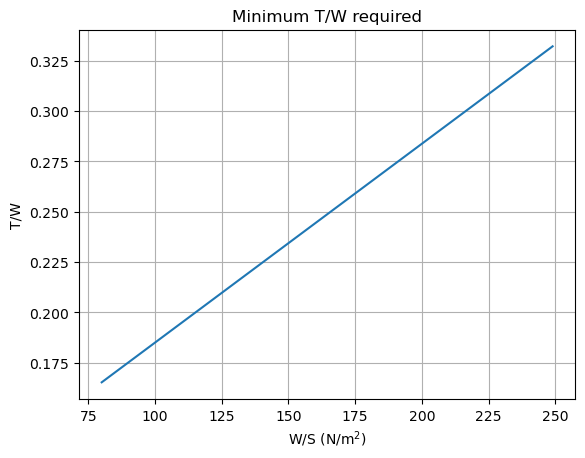

In [20]:
plt.plot(wingloadinglist,twratio)
plt.ylabel("T/W")
plt.xlabel("W/S (N/m$^2$)")
plt.title("Minimum T/W required")
plt.grid(True)
plt.show()

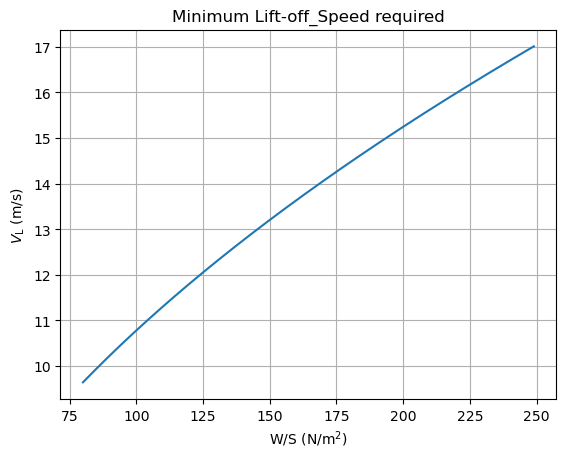

In [21]:
plt.plot(wingloadinglist,liftoffspeed_mpstas)
plt.ylabel("$V_\mathrm{L}$ (m/s)")
plt.xlabel("W/S (N/m$^2$)")
plt.title("Minimum Lift-off_Speed required")
plt.grid(True)
plt.show()

# Sensitivity Analysis

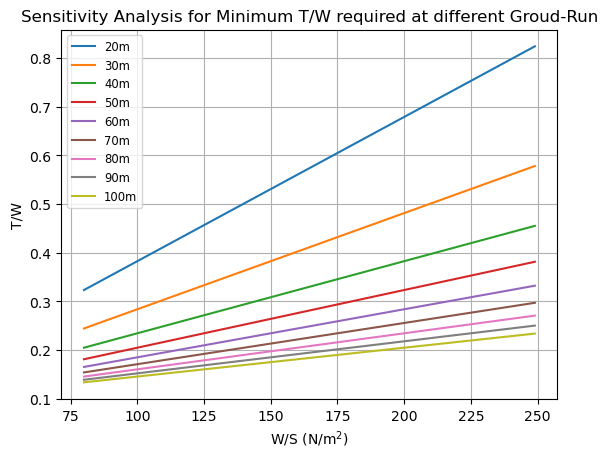

In [23]:
# Effect of Change in Ground_run on T/W 
for groundrun_m in [20,30,40,50,60,70,80,90,100]:
    design_brief={"groundrun_m":groundrun_m}                                     
    concept=ca.AircraftConcept(design_brief,design_definition,design_performance,design_atm)
    twratio,liftoffspeed_mpstas=concept.thrusttoweight_takeoff(wingloadinglist)
    plt.plot(wingloadinglist,twratio,label=str(groundrun_m)+"m")
    plt.ylabel("T/W")
    plt.xlabel("W/S (N/m$^2$)")
    plt.title("Sensitivity Analysis for Minimum T/W required at different Groud-Run")
    plt.grid(True)
legend=plt.legend(loc="upper left",fontsize="small")

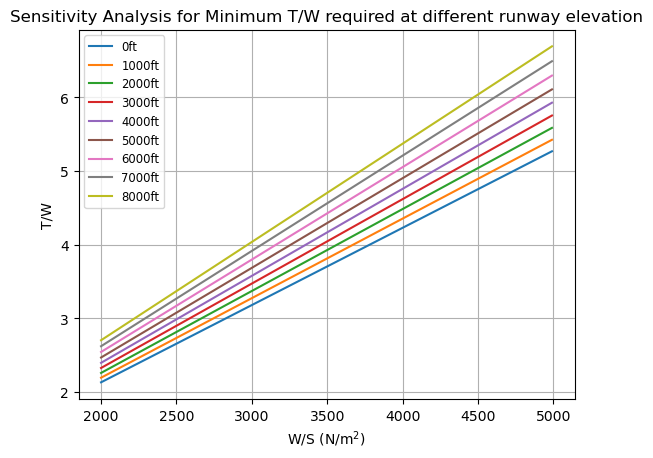

In [37]:
design_brief={"groundrun_m":60}
# Effect of change in elevations on T/W 
for elevation_ft in [0,1000,2000,3000,4000,5000,6000,7000,8000]:  
    design_brief={"groundrun_m":60,"rwyelevation_m":co.feet2m(elevation_ft)}
    concept=ca.AircraftConcept(design_brief,design_definition,design_performance,design_atm)
    twratio,liftoffspeed_mpstas=concept.thrusttoweight_takeoff(wingloadinglist)
    plt.plot(wingloadinglist,twratio,label=str(elevation_ft)+"ft")
    plt.ylabel("T/W")
    plt.xlabel("W/S (N/m$^2$)")
    plt.title("Sensitivity Analysis for Minimum T/W required at different runway elevation")
    plt.grid(True)
legend=plt.legend(loc="upper left",fontsize="small")

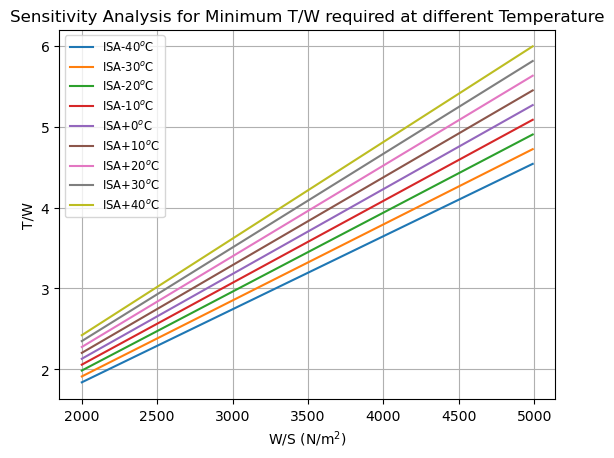

In [38]:
design_brief={"groundrun_m":60,"rwelevation":0}
# Effect of Atmospheric Temperature Change on T/W 
for tmp_offset_deg in [-40,-30,-20,-10,0,10,20,30,40]:  
    design_atm=at.Atmosphere(offset_deg=tmp_offset_deg)
    concept=ca.AircraftConcept(design_brief,design_definition,design_performance,design_atm)
    twratio,liftoffspeed_mpstas=concept.thrusttoweight_takeoff(wingloadinglist)
    if tmp_offset_deg<0:
        plt.plot(wingloadinglist,twratio,label="ISA"+str(tmp_offset_deg)+"$^o$C")
    else:
        plt.plot(wingloadinglist,twratio,label="ISA+"+str(tmp_offset_deg)+"$^o$C")
plt.ylabel("T/W")
plt.xlabel("W/S (N/m$^2$)")
plt.title("Sensitivity Analysis for Minimum T/W required at different Temperature")
plt.grid(True)
legend=plt.legend(loc="upper left",fontsize="small")

# Thrust Mapping for Piston Engine Aircraft

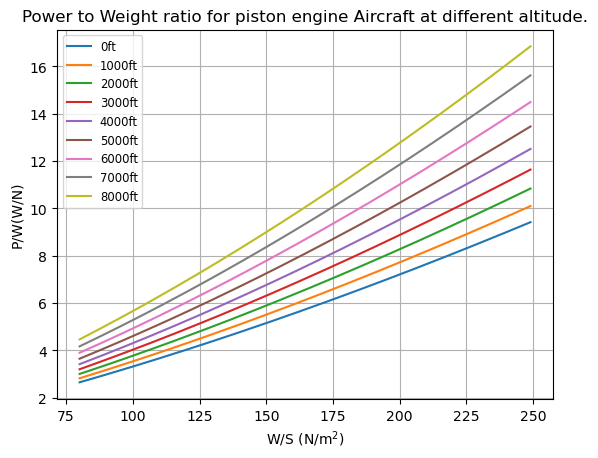

In [26]:
design_definition={"aspectratio":9,"bpr":-1}                                   # -1 is for piston engine.
etap={"take-off":0.6,"climb":0.75,"cruise":0.85,"turn":0.85,"servceil":0.6}    # various propeller eff. at different phases for a propeller driven aircraft
design_performance={"CDTO":0.0898,"CLTO":0.97,"CLmaxTO":1.7,"mu_R":0.08,"etaprop":etap}
design_atm=at.Atmosphere()
for elevation_ft in [0,1000,2000,3000,4000,5000,6000,7000,8000]:  
    design_brief={"groundrun_m":60,"rwyelevation_m":co.feet2m(elevation_ft)}
    concept=ca.AircraftConcept(design_brief,design_definition,design_performance,design_atm)
    gffactor=at.pistonpowerfactor(design_atm.airdens_kgpm3(co.feet2m(elevation_ft)))
    twratio,liftoffspeed_mpstas=concept.thrusttoweight_takeoff(wingloadinglist)

    pwratio=(1/gffactor)*ca.tw2pw(twratio,liftoffspeed_mpstas,etap["take-off"])
    plt.plot(wingloadinglist,pwratio,label=str(elevation_ft)+"ft")
plt.ylabel("P/W(W/N)")
plt.xlabel("W/S (N/m$^2$)")
plt.title("Power to Weight ratio for piston engine Aircraft at different altitude.")
plt.grid(True)
legend=plt.legend(loc="upper left",fontsize="small")

# Thrust Mapping for Gas Turbine Engine

In [27]:
design_brief={"rwyelevation_m":1000,"groundrun_m":1200}                                             
design_definition={"aspectratio":7.3,"bpr":3.9,"tr":1.05}               # tr=throttle ratio(Air to fuel ratio)                                 
design_performance={"CDTO":0.04,"CLTO":0.9,"CLmaxTO":1.6,"mu_R":0.02}

In [28]:
# Wing-Loading
wingloadinglist=np.arange(2000,5000,10)
print(wingloadinglist)

[2000 2010 2020 2030 2040 2050 2060 2070 2080 2090 2100 2110 2120 2130
 2140 2150 2160 2170 2180 2190 2200 2210 2220 2230 2240 2250 2260 2270
 2280 2290 2300 2310 2320 2330 2340 2350 2360 2370 2380 2390 2400 2410
 2420 2430 2440 2450 2460 2470 2480 2490 2500 2510 2520 2530 2540 2550
 2560 2570 2580 2590 2600 2610 2620 2630 2640 2650 2660 2670 2680 2690
 2700 2710 2720 2730 2740 2750 2760 2770 2780 2790 2800 2810 2820 2830
 2840 2850 2860 2870 2880 2890 2900 2910 2920 2930 2940 2950 2960 2970
 2980 2990 3000 3010 3020 3030 3040 3050 3060 3070 3080 3090 3100 3110
 3120 3130 3140 3150 3160 3170 3180 3190 3200 3210 3220 3230 3240 3250
 3260 3270 3280 3290 3300 3310 3320 3330 3340 3350 3360 3370 3380 3390
 3400 3410 3420 3430 3440 3450 3460 3470 3480 3490 3500 3510 3520 3530
 3540 3550 3560 3570 3580 3590 3600 3610 3620 3630 3640 3650 3660 3670
 3680 3690 3700 3710 3720 3730 3740 3750 3760 3770 3780 3790 3800 3810
 3820 3830 3840 3850 3860 3870 3880 3890 3900 3910 3920 3930 3940 3950
 3960 

In [29]:
# Atmosphere
design_atm=at.Atmosphere()
concept=ca.AircraftConcept(design_brief,design_definition,design_performance,design_atm)

In [30]:
# Thrust to Weight ratio for Take-off
twratio,liftoffspeed_mpstas=concept.thrusttoweight_takeoff(wingloadinglist)

In [31]:
twratio1=concept.map2static()*twratio                   # it maps the avg take-off thrust to static thrust.
temp_c=design_atm.airtemp_c(design_brief["rwyelevation_m"])
pressure_pa=design_atm.airpress_pa(design_brief["rwyelevation_m"])
mach=design_atm.mach(liftoffspeed_mpstas,design_brief["rwyelevation_m"])
throttleratio=design_definition["tr"]
correctionvec=[]
for i,tw in enumerate(twratio):
    twratio_altcorr=at.turbofanthrustfactor(temp_c,pressure_pa,mach[i],throttleratio,"lowbpr")    # calculates twratio at particular condition.
    correctionvec.append(twratio_altcorr)

In [32]:
twratio2=twratio1/twratio_altcorr

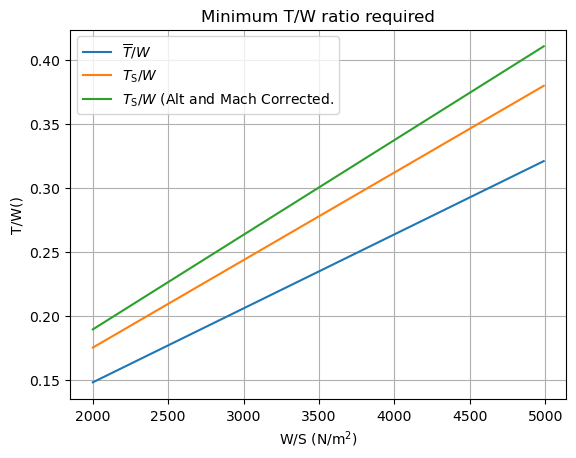

In [33]:
plt.plot(wingloadinglist,twratio,label="$\overline{T}/W$")
plt.plot(wingloadinglist,twratio1,label="$T_\mathrm{S}/W$")
plt.plot(wingloadinglist,twratio2,label="$T_\mathrm{S}/W$ (Alt and Mach Corrected.")
legend=plt.legend(loc="upper left")
plt.ylabel("T/W()")
plt.xlabel("W/S (N/m$^2$)")
plt.title("Minimum T/W ratio required")
plt.grid(True)
plt.show()